<a href="https://colab.research.google.com/github/Arisha2902/ML-Project/blob/main/mlproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd

In [4]:
columns = ['engine_id', 'cycle', 'op1', 'op2', 'op3',
           's1','s2','s3','s4','s5','s6','s7','s8','s9',
           's10','s11','s12','s13','s14','s15','s16',
           's17','s18','s19','s20','s21']

In [5]:
df = pd.read_csv('train_FD001.txt', sep='\s+', header=None, names=columns)

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_624/2507252961.py:1: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv('train_FD001.txt', sep='\s+', header=None, names=columns)


In [6]:
df.head()

,engine_id,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [7]:
df.std

<bound method DataFrame.std of        engine_id  cycle     op1     op2    op3      s1      s2       s3  \
0              1      1 -0.0007 -0.0004  100.0  518.67  641.82  1589.70   
1              1      2  0.0019 -0.0003  100.0  518.67  642.15  1591.82   
2              1      3 -0.0043  0.0003  100.0  518.67  642.35  1587.99   
3              1      4  0.0007  0.0000  100.0  518.67  642.35  1582.79   
4              1      5 -0.0019 -0.0002  100.0  518.67  642.37  1582.85   
...          ...    ...     ...     ...    ...     ...     ...      ...   
20626        100    196 -0.0004 -0.0003  100.0  518.67  643.49  1597.98   
20627        100    197 -0.0016 -0.0005  100.0  518.67  643.54  1604.50   
20628        100    198  0.0004  0.0000  100.0  518.67  643.42  1602.46   
20629        100    199 -0.0011  0.0003  100.0  518.67  643.23  1605.26   
20630        100    200 -0.0032 -0.0005  100.0  518.67  643.85  1600.38   

            s4     s5  ...     s12      s13      s14     s15   s16  s17   s18  \
0      1400.60  14.62  ...  521.66  2388.02  8138.62  8.4195  0.03  392  2388   
1      1403.14  14.62  ...  522.28  2388.07  8131.49  8.4318  0.03  392  2388   
2      1404.20  14.62  ...  522.42  2388.03  8133.23  8.4178  0.03  390  2388   
3      1401.87  14.62  ...  522.86  2388.08  8133.83  8.3682  0.03  392  2388   
4      1406.22  14.62  ...  522.19  2388.04  8133.80  8.4294  0.03  393  2388   
...        ...    ...  ...     ...      ...      ...     ...   ...  ...   ...   
20626  1428.63  14.62  ...  519.49  2388.26  8137.60  8.4956  0.03  397  2388   
20627  1433.58  14.62  ...  519.68  2388.22  8136.50  8.5139  0.03  395  2388   
20628  1428.18  14.62  ...  520.01  2388.24  8141.05  8.5646  0.03  398  2388   
20629  1426.53  14.62  ...  519.67  2388.23  8139.29  8.5389  0.03  395  2388   
20630  1432.14  14.62  ...  519.30  2388.26  8137.33  8.5036  0.03  396  2388   

         s19    s20      s21  
0      100.0  39.06  23.4190  
1      100.0  39.00  23.4236  
2      100.0  38.95  23.3442  
3      100.0  38.88  23.3739  
4      100.0  38.90  23.4044  
...      ...    ...      ...  
20626  100.0  38.49  22.9735  
20627  100.0  38.30  23.1594  
20628  100.0  38.44  22.9333  
20629  100.0  38.29  23.0640  
20630  100.0  38.37  23.0522  

[20631 rows x 26 columns]>

In [8]:
constant_cols = [col for col in df.columns if df[col].std() == 0]
print("Constant sensors:", constant_cols)
df = df.drop(columns=constant_cols)

Constant sensors: ['op3', 's18', 's19']


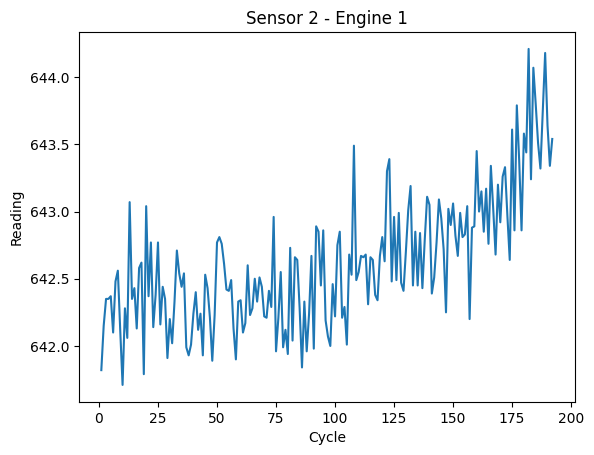

In [9]:
import matplotlib.pyplot as plt

engine_1 = df[df['engine_id'] == 1]

plt.plot(engine_1['cycle'], engine_1['s2'])
plt.title('Sensor 2 - Engine 1')
plt.xlabel('Cycle')
plt.ylabel('Reading')
plt.show()

In [10]:

df = df.sort_values(['engine_id', 'cycle'])


In [11]:
df['s2_rolling_mean_5'] = df.groupby('engine_id')['s2'].transform(
    lambda x: x.rolling(window=5, min_periods=1).mean()
)

If rolling std is LOW  → sensor is stable → engine probably healthy
If rolling std is HIGH → sensor is jumping around → engine possibly degrading


In [12]:
df['s2_rolling_std_5'] = df.groupby('engine_id')['s2'].transform(
    lambda x: x.rolling(window=5, min_periods=1).std()
)

In [13]:
df['s2_diff'] = df.groupby('engine_id')['s2'].transform(
    lambda x: x.diff()
)

In [14]:
# Find the last cycle for each engine (that's when it failed)
max_cycles = df.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.columns = ['engine_id', 'max_cycle']

# Merge and calculate RUL
df = df.merge(max_cycles, on='engine_id')
df['RUL'] = df['max_cycle'] - df['cycle']
df = df.drop(columns=['max_cycle'])

In [15]:
engine_1 = df[df['engine_id'] == 1][['cycle', 's2', 's2_rolling_mean_5',
                                      's2_rolling_std_5', 's2_diff']].head(20)
print(engine_1)

    cycle      s2  s2_rolling_mean_5  s2_rolling_std_5  s2_diff
0       1  641.82         641.820000               NaN      NaN
1       2  642.15         641.985000          0.233345     0.33
2       3  642.35         642.106667          0.267644     0.20
3       4  642.35         642.167500          0.250117     0.00
4       5  642.37         642.208000          0.234776     0.02
5       6  642.10         642.264000          0.128374    -0.27
6       7  642.48         642.330000          0.139463     0.38
7       8  642.56         642.372000          0.174270     0.08
8       9  642.12         642.326000          0.208519    -0.44
9      10  641.71         642.194000          0.340705    -0.41
10     11  642.28         642.230000          0.337787     0.57
11     12  642.06         642.146000          0.311256    -0.22
12     13  643.07         642.248000          0.504450     1.01
13     14  642.35         642.294000          0.500330    -0.72
14     15  642.43         642.438000    

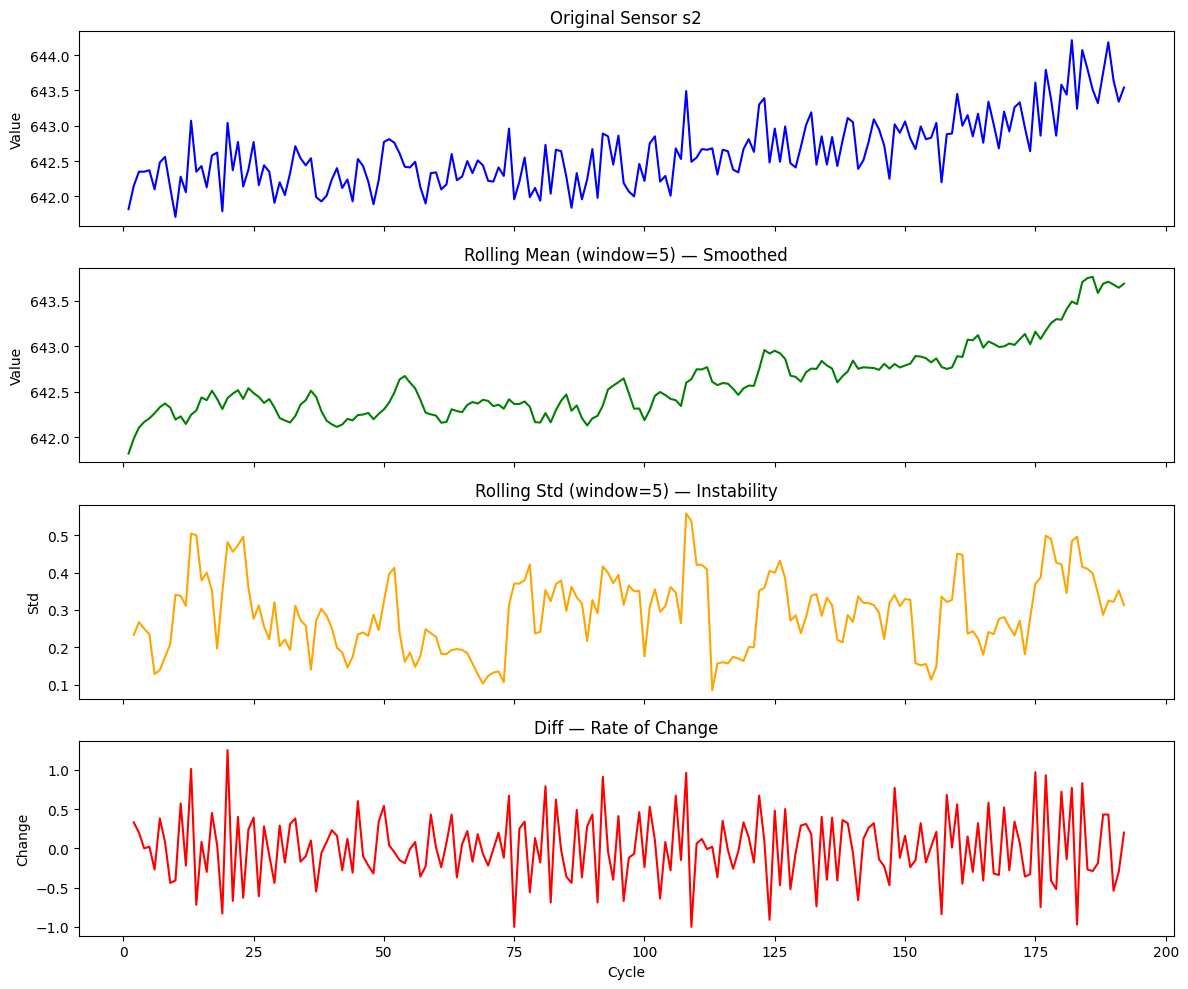

In [16]:
import matplotlib.pyplot as plt

engine_1 = df[df['engine_id'] == 1]

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# Original sensor
axes[0].plot(engine_1['cycle'], engine_1['s2'], color='blue')
axes[0].set_title('Original Sensor s2')
axes[0].set_ylabel('Value')

# Rolling Mean
axes[1].plot(engine_1['cycle'], engine_1['s2_rolling_mean_5'], color='green')
axes[1].set_title('Rolling Mean (window=5) — Smoothed')
axes[1].set_ylabel('Value')

# Rolling Std
axes[2].plot(engine_1['cycle'], engine_1['s2_rolling_std_5'], color='orange')
axes[2].set_title('Rolling Std (window=5) — Instability')
axes[2].set_ylabel('Std')

# Diff
axes[3].plot(engine_1['cycle'], engine_1['s2_diff'], color='red')
axes[3].set_title('Diff — Rate of Change')
axes[3].set_ylabel('Change')
axes[3].set_xlabel('Cycle')

plt.tight_layout()
plt.savefig('sensor_analysis.png')  # saves the image
plt.show()

In [17]:
engine_1 = df[df['engine_id'] == 1][['cycle', 'RUL']].tail(10)
print(engine_1)

     cycle  RUL
182    183    9
183    184    8
184    185    7
185    186    6
186    187    5
187    188    4
188    189    3
189    190    2
190    191    1
191    192    0


In [18]:
corr = df.corr()['RUL'].sort_values()
print(corr)

cycle               -0.736241
s2_rolling_mean_5   -0.711861
s11                 -0.696228
s4                  -0.678948
s15                 -0.642667
s2                  -0.606484
s17                 -0.606154
s3                  -0.584520
s8                  -0.563968
s13                 -0.562569
s9                  -0.390102
s14                 -0.306769
s6                  -0.128348
s2_diff             -0.013431
s2_rolling_std_5    -0.005516
op1                 -0.003198
op2                 -0.001948
engine_id            0.078753
s20                  0.629428
s21                  0.635662
s7                   0.657223
s12                  0.671983
RUL                  1.000000
s1                        NaN
s5                        NaN
s10                       NaN
s16                       NaN
Name: RUL, dtype: float64


In [19]:
df = df.dropna()

In [20]:
drop_cols = ['engine_id', 'cycle', 'RUL', 'op1', 'op2']

X = df.drop(columns=drop_cols)
y = df['RUL']


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
X_train_scaled.isnull().sum()

AttributeError: 'numpy.ndarray' object has no attribute 'isnull'

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"Linear Regression RMSE: {rmse:.2f}")
print(f"Linear Regression MAE:  {mae:.2f}")

Linear Regression RMSE: 43.87
Linear Regression MAE:  33.60


In [25]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"Random Forest RMSE: {rmse_rf:.2f}")
print(f"Random Forest MAE:  {mae_rf:.2f}")

Random Forest RMSE: 40.76
Random Forest MAE:  28.99


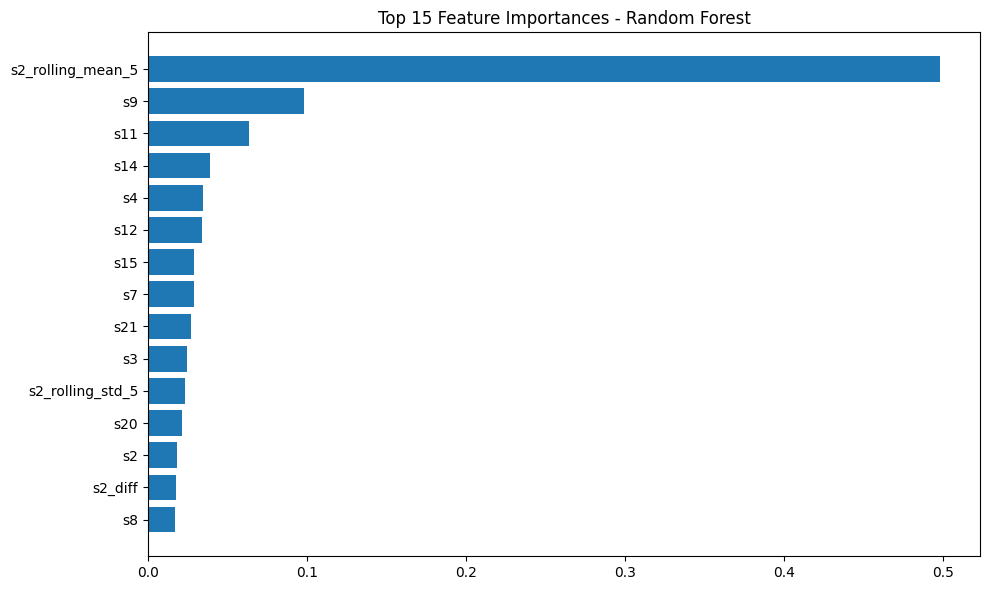

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = X.columns
importances = rf.feature_importances_

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(feat_df['Feature'], feat_df['Importance'])
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

In [27]:
print(X.shape)
print(X.columns.tolist())

(20531, 22)
['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's20', 's21', 's2_rolling_mean_5', 's2_rolling_std_5', 's2_diff']


In [28]:
corr = df.corr()['RUL'].sort_values()
print(corr)

cycle               -0.734210
s2_rolling_mean_5   -0.712912
s11                 -0.696693
s4                  -0.679193
s15                 -0.643450
s2                  -0.606835
s17                 -0.606122
s3                  -0.584563
s8                  -0.564499
s13                 -0.562857
s9                  -0.389888
s14                 -0.306571
s6                  -0.127239
s2_diff             -0.013431
s2_rolling_std_5    -0.005516
op1                 -0.002546
op2                 -0.001726
engine_id            0.079150
s20                  0.630111
s21                  0.635858
s7                   0.657437
s12                  0.672364
RUL                  1.000000
s1                        NaN
s5                        NaN
s10                       NaN
s16                       NaN
Name: RUL, dtype: float64


In [30]:
useful_sensors = ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']

for sensor in useful_sensors:
    df[f'{sensor}_rolling_mean_5'] = df.groupby('engine_id')[sensor].transform(
        lambda x: x.rolling(window=5, min_periods=1).mean()
    )
    df[f'{sensor}_rolling_std_5'] = df.groupby('engine_id')[sensor].transform(
        lambda x: x.rolling(window=5, min_periods=1).std()
    )
    df[f'{sensor}_diff'] = df.groupby('engine_id')[sensor].transform(
        lambda x: x.diff()
    )

print(f"Total features now: {df.shape[1]}")

Total features now: 66


In [32]:
drop_cols = ['engine_id', 'cycle', 'RUL', 'op1', 'op2']

X = df.drop(columns=drop_cols)
y = df['RUL']

X = X.fillna(0)

print(X.shape)
print(X.columns.tolist())

(20531, 61)
['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's20', 's21', 's2_rolling_mean_5', 's2_rolling_std_5', 's2_diff', 's3_rolling_mean_5', 's3_rolling_std_5', 's3_diff', 's4_rolling_mean_5', 's4_rolling_std_5', 's4_diff', 's7_rolling_mean_5', 's7_rolling_std_5', 's7_diff', 's8_rolling_mean_5', 's8_rolling_std_5', 's8_diff', 's9_rolling_mean_5', 's9_rolling_std_5', 's9_diff', 's11_rolling_mean_5', 's11_rolling_std_5', 's11_diff', 's12_rolling_mean_5', 's12_rolling_std_5', 's12_diff', 's13_rolling_mean_5', 's13_rolling_std_5', 's13_diff', 's14_rolling_mean_5', 's14_rolling_std_5', 's14_diff', 's15_rolling_mean_5', 's15_rolling_std_5', 's15_diff', 's17_rolling_mean_5', 's17_rolling_std_5', 's17_diff', 's20_rolling_mean_5', 's20_rolling_std_5', 's20_diff', 's21_rolling_mean_5', 's21_rolling_std_5', 's21_diff']


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"Linear Regression RMSE: {rmse:.2f}")
print(f"Linear Regression MAE:  {mae:.2f}")

Linear Regression RMSE: 43.30
Linear Regression MAE:  33.12


In [36]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"Random Forest RMSE: {rmse_rf:.2f}")
print(f"Random Forest MAE:  {mae_rf:.2f}")

Random Forest RMSE: 35.32
Random Forest MAE:  24.68
